# Diffusion Models Session – Part 3: Fast Sampling with DDIM

**Alejandro Lancho Serrano, Vanessa Gómez Verdejo, Pablo Martínez Olmos, Emilio Parrado Hernández**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~emipar/BBVA/INTRO/img/logo_uc3m_foot.jpg' width=400 />

## Table of Contents

1. [Recap & Objectives](#recap-objectives)  
2. [Setting Things Up](#setup)  
3. [Dataset](#dataset)  
4. [Diffusion Recap](#diffusion-recap)  
5. [DDIM Theory](#ddim-theory)  
6. [Models & Checkpoints](#models-checkpoints)  
7. [DDIM Sampling](#ddim-sampling)  
8. [Discussion & Takeaways](#discussion)  
9. [Acknowledgments](#acknowledgments)  

## Recap and objectives <a id="recap-objectives"></a>

Parts 1 and 2 trained DDPM models (unconditional and conditional) and sampled them with the ancestral loop. That sampler is slow: it spends hundreds to a thousand network evaluations per image. Here we keep those exact models and swap in **DDIM**, which reaches similar quality in 20–50 steps and exposes a single knob $\eta$ that slides from the stochastic DDPM sampler to a fast deterministic one. A GPU is recommended.


## Setting Things Up <a id="setup"></a>

In [1]:
# Set up the working directory dynamically
import os
import sys

In [2]:
# # If you're using Google Colab, uncomment the following lines to mount Google Drive
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # Define your directory path relative to your Google Drive base directory
# base_path = '/content/drive/My Drive/BBVA_cursos/MATERIAL_CURSOS/GEN_AI/Session_diffusion'

# # Add the base path to the system path for module imports
# if base_path not in sys.path:
#     sys.path.append(base_path)

# # Change the current working directory to the base path
# os.chdir(base_path)


In [3]:
from typing import Dict, Tuple  # For type annotations, making the code easier to understand and debug.
from tqdm import tqdm  # For displaying progress bars during loops (e.g., training or sampling).
import torch
import torch.nn as nn  # For defining neural network modules.
import torch.nn.functional as F  # For functional operations like activation functions or loss calculations.
from torch.utils.data import DataLoader  # For efficient data batching and loading.
from torchvision import models, transforms  # Predefined models and data transformations.
from torchvision.utils import save_image, make_grid  # For saving and visualizing images.
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter  # For creating and saving animations (e.g., visualization of diffusion steps).
import numpy as np
from IPython.display import HTML  # For displaying HTML content like animations in Jupyter notebooks.
from diffusion_utilities import *  # This is an auxiliary file provided with some useful functions/classes.
import requests  # For making HTTP requests to download files directly from URLs.
from io import BytesIO  # For handling in-memory binary streams (used when loading files from URLs without saving to disk).

## Dataset <a id="dataset"></a>

We reuse the **pixel-art sprites** from Parts 1 and 2, loaded through the `CustomDataset` helper in `diffusion_utilities.py`. We are not training here, only sampling, but we load the data so we can compare generated sprites against the real ones and reuse the same labels for conditional DDIM.


In [4]:
# load dataset like this if you have it in your directory
# dataset = CustomDataset("./sprites_1788_16x16.npy", "./sprite_labels_nc_1788_16x16.npy", transform, null_context=False)

def download_file(url, local_filename):
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(local_filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    return local_filename

# Build full URLs
base_url = "https://huggingface.co/datasets/a-lancho/genAI-course-sprites/resolve/main/"

sprites_url = base_url + "sprites_1788_16x16.npy"
labels_url = base_url + "sprite_labels_nc_1788_16x16.npy"

# Download to local files
download_file(sprites_url, "sprites.npy")
download_file(labels_url, "labels.npy")

batch_size = 100 # Needed for the dataloader

# Now you can use your class as before:
dataset = CustomDataset("sprites.npy", "labels.npy", transform, null_context=False)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=1)

# construct optimizer
#optim = torch.optim.Adam(nn_model.parameters(), lr=lrate)

sprite shape: (89400, 16, 16, 3)
labels shape: (89400, 5)


## Diffusion recap <a id="diffusion-recap"></a>

Two processes. The **forward process** adds Gaussian noise to a clean image $x_0$ over $T$ steps; with the per-step factor $\alpha_t=1-\beta_t$ and the cumulative product $\bar\alpha_t=\prod_{s\le t}\alpha_s$ it has the one-shot form
$$ x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon,\qquad \varepsilon\sim\mathcal{N}(0,I). $$
The **reverse process** is what the network learns: predict the noise $\varepsilon_\theta(x_t,t)$, recover the clean-data guess $\hat x_0$, and step back. The ancestral (DDPM) reverse step is
$$ x_{t-1}=\tfrac{1}{\sqrt{\alpha_t}}\Big(x_t-\tfrac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\Big)+\sigma_t z,\qquad z\sim\mathcal{N}(0,I). $$
Each step is deliberately small because of the fresh $\sigma_t z$, so good samples need many steps. DDIM removes that bottleneck.


## DDIM: reuse the noise you already inferred <a id="ddim-theory"></a>

DDPM sampling works but is slow: each reverse step injects fresh noise, which forces the steps to be tiny, so a good sample costs on the order of a thousand network evaluations. DDIM (Song, Meng & Ermon, 2021) gets similar quality in 20–50 steps with the same trained network, and the "fill in $x_0$, then step back" picture makes it almost immediate.

### Where the slowness comes from
Each ancestral step forms the network's estimate $\hat x_0$ (equivalently $\hat\varepsilon=\varepsilon_\theta(x_t,t)$) and then draws
$$ x_{t-1}\sim\mathcal{N}\big(c_1(t)\,x_t+c_2(t)\,\hat x_0,\ \tilde\beta_t I\big). $$
The variance $\tilde\beta_t$ is fresh, independent noise added on top of the inferred mean. That fresh randomness is exactly what forces small steps: a large step would inject large noise that takes many later steps to average out.

### The idea
When the network returns $\hat x_0$ and $\hat\varepsilon$, it asserts a specific decomposition of the current state,
$$ x_t=\sqrt{\bar\alpha_t}\,\hat x_0+\sqrt{1-\bar\alpha_t}\,\hat\varepsilon. $$
DDPM throws $\hat\varepsilon$ away and draws new noise. DDIM instead *believes* the decomposition: keep $\hat x_0$ and $\hat\varepsilon$, and re-noise $\hat x_0$ to the next level using the *same* $\hat\varepsilon$,
$$ x_{t-1}=\sqrt{\bar\alpha_{t-1}}\,\hat x_0+\sqrt{1-\bar\alpha_{t-1}}\,\hat\varepsilon. $$
No random draw enters, so the step is deterministic. Trusting the inference removes the randomness, and removing the randomness is what lets the step be large.

### One knob: the noise level $\sigma_t$
There is no need to choose between all-fresh and no-fresh noise. A one-parameter family interpolates,
$$ x_{t-1}=\sqrt{\bar\alpha_{t-1}}\,\hat x_0+\sqrt{1-\bar\alpha_{t-1}-\sigma_t^2}\;\hat\varepsilon+\sigma_t z,\qquad z\sim\mathcal{N}(0,I), $$
with $\sigma_t=\eta\sqrt{\tilde\beta_t}$ and $\eta\in[0,1]$. The first term is the *reused* share of the inferred noise; $\sigma_t z$ is the share we choose to replace with fresh noise. The split keeps the total noise level exactly at $1-\bar\alpha_{t-1}$. Setting $\eta=1$ recovers the stochastic DDPM step; $\eta=0$ gives the deterministic DDIM step. For a skipped jump $t\to t'$ the same formula holds with $\bar\alpha_{t-1}$ replaced by $\bar\alpha_{t'}$ and
$$ \sigma_t=\eta\,\sqrt{\tfrac{1-\bar\alpha_{t'}}{1-\bar\alpha_t}}\,\sqrt{1-\tfrac{\bar\alpha_t}{\bar\alpha_{t'}}}. $$

### Why the same network still works, and why it is fast
The family was built to preserve the marginals: every member corresponds to a process whose per-time marginals $q(x_t\mid x_0)=\mathcal{N}(\sqrt{\bar\alpha_t}\,x_0,(1-\bar\alpha_t)I)$ are identical to the ones training used, for every $\sigma_t$. Our loss only ever saw those marginals, so the trained $\varepsilon_\theta$ is exactly what the formula needs, with no retraining. The Markovian DDPM chain was just one member of a larger family.

Setting $\eta=0$ makes the whole trajectory deterministic, with two consequences. Smooth paths can be traversed in far fewer steps (20–50 against a thousand), evaluating the network on any subsequence of times we like. And a deterministic map is invertible: run it backwards to encode a real image into the noise that regenerates it, which is what makes DDIM latents useful for interpolation and editing.

### Why not jump straight from $T$ to $0$?
The formula allows it, but at $t=T$ the input is essentially pure noise, and asking the network to recover everything in one pass is unrealistic. Gradual denoising spreads the error correction across steps. In practice 20–50 steps strike the balance; far fewer loses detail.


### Seeing the difference in 2D

The two-moons toy makes the contrast concrete. Using the analytic posterior mean $\mathbb{E}[x_0\mid x_t]$ as a stand-in for a perfectly trained denoiser, we run the reverse process from the *same* starting noise two ways: DDPM ($\eta=1$, fresh noise each step) and DDIM ($\eta=0$, reuse the inferred noise). DDPM wanders, its randomness averaging out only over many steps; DDIM follows a smooth, fixed path onto the data. Same denoiser, same start, different step rule.


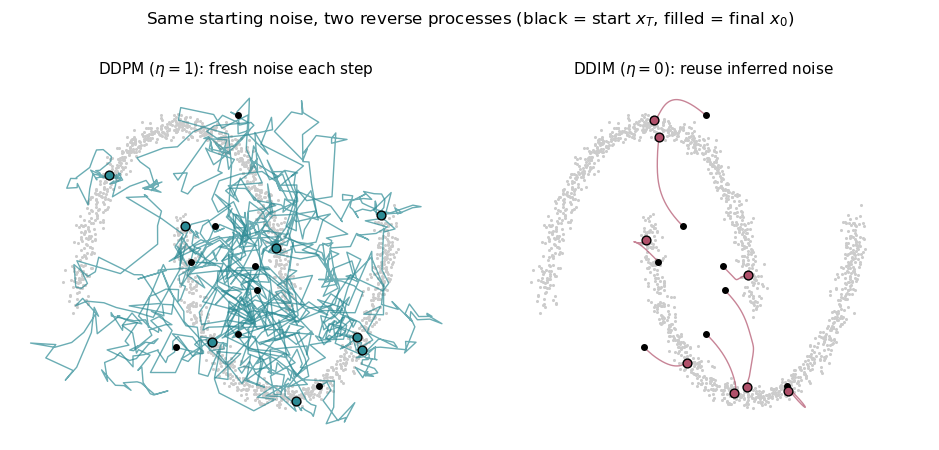

In [5]:
# --- self-contained 2D illustration (numpy + matplotlib only; no GPU, no model) ---
import numpy as np
import matplotlib.pyplot as plt

rng_toy = np.random.default_rng(3)

def two_moons(n, noise=0.08, rng=None):
    rng = rng or np.random.default_rng()
    n1, n2 = n // 2, n - n // 2
    a = np.pi * rng.random(n1); m1 = np.stack([np.cos(a), np.sin(a)], 1)
    b = np.pi * rng.random(n2); m2 = np.stack([1 - np.cos(b), 0.5 - np.sin(b)], 1)
    X = np.concatenate([m1, m2], 0); X = (X - X.mean(0)) / X.std(0) * 1.3
    return (X + noise * rng.normal(size=X.shape)).astype(float)

X0_toy = two_moons(1500, rng=rng_toy)
T_toy = 150
beta_toy = np.linspace(5e-4, 0.08, T_toy)
abar_toy = np.cumprod(1.0 - beta_toy)
abar_toy_prev = np.r_[1.0, abar_toy[:-1]]

def xhat0_toy(xt, t):
    # analytic posterior mean E[x0 | xt] using the data cloud as the prior (a "perfect" denoiser)
    a = abar_toy[t - 1]
    d2 = ((xt[:, None, :] - np.sqrt(a) * X0_toy[None, :, :]) ** 2).sum(2) / (1 - a)
    d2 -= d2.min(1, keepdims=True)
    w = np.exp(-0.5 * d2); w /= w.sum(1, keepdims=True)
    return w @ X0_toy

def q_sample_toy(x0, t, rng):
    a = abar_toy[t - 1]
    return np.sqrt(a) * x0 + np.sqrt(1 - a) * rng.normal(size=x0.shape)

# same starting noise x_T for both samplers
n_paths = 8
src = X0_toy[rng_toy.choice(len(X0_toy), n_paths, replace=False)]
xT_toy = q_sample_toy(src, T_toy, rng_toy)

def run_reverse(eta, rng):
    x = xT_toy.copy(); traj = [x.copy()]
    for t in range(T_toy, 0, -1):
        a = abar_toy[t - 1]; ap = abar_toy_prev[t - 1]
        xh = xhat0_toy(x, t)
        eps = (x - np.sqrt(a) * xh) / np.sqrt(1 - a)               # inferred noise
        sigma = eta * np.sqrt((1 - ap) / (1 - a)) * np.sqrt(max(1e-12, 1 - a / ap)) if ap < 1 else 0.0
        reused = np.sqrt(max(0.0, 1 - ap - sigma ** 2)) * eps
        z = rng.normal(size=x.shape) if t > 1 else 0.0
        x = np.sqrt(ap) * xh + reused + sigma * z
        traj.append(x.copy())
    return np.array(traj)

tr_ddpm = run_reverse(1.0, np.random.default_rng(11))
tr_ddim = run_reverse(0.0, np.random.default_rng(11))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6), sharex=True, sharey=True)
for ax, (tr, title, col) in zip(axes, [(tr_ddpm, r"DDPM ($\eta=1$): fresh noise each step", "#2B8A94"),
                                        (tr_ddim, r"DDIM ($\eta=0$): reuse inferred noise", "#B0506A")]):
    ax.scatter(X0_toy[:, 0], X0_toy[:, 1], s=5, c="0.8", linewidths=0, zorder=0)
    for k in range(n_paths):
        ax.plot(tr[:, k, 0], tr[:, k, 1], color=col, alpha=0.7, lw=1.0, zorder=2)
        ax.scatter(tr[0, k, 0], tr[0, k, 1], c="k", s=16, zorder=3)
        ax.scatter(tr[-1, k, 0], tr[-1, k, 1], c=col, s=40, edgecolor="k", zorder=4)
    ax.set_title(title, fontsize=11); ax.set_aspect("equal"); ax.axis("off")
fig.suptitle("Same starting noise, two reverse processes (black = start $x_T$, filled = final $x_0$)", y=1.01)
plt.tight_layout(); plt.show()


## Models and checkpoints

This notebook does not train; it loads the networks from Parts 1 and 2 and runs DDIM on them.

- `nn_model`: the **unconditional** U-Net predicting $\varepsilon_\theta(x_t,t)$ (Part 1).
- `nn_model_ctx`: the **conditional** Context U-Net predicting $\varepsilon_\theta(x_t,t,c)$ (Part 2).

We use the exact architectures from the previous notebooks and the `model_31` / `context_model_31` checkpoints, then set the models to `.eval()`.


In [6]:
# Hyperparameters

# Diffusion hyperparameters
timesteps = 500  # Number of timesteps for the forward and reverse diffusion processes
beta1 = 1e-4     # Starting value for the beta schedule (variance of noise added in the forward process)
beta2 = 0.02     # Final value for the beta schedule

# Network hyperparameters
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")  # Device configuration: Use GPU if available, otherwise use CPU
n_feat = 64  # Number of hidden dimensions for features (controls model capacity)
n_cfeat = 5 # context vector is of size 5
height = 16  # Spatial size of the input image (assumes square images of size 16x16)
save_dir = './weights/'  # Directory to save trained model weights

# Training hyperparameters
batch_size = 100  # Number of samples per training batch
n_epoch = 32      # Number of training epochs
lrate = 1e-3      # Initial learning rate for the optimizer


In [7]:
# ----- DDPM noise schedule (fixed), same as Parts 1 and 2 -----
print("Using", device)

b_t = (beta2 - beta1) * torch.linspace(0, 1, timesteps + 1, device=device) + beta1
a_t = 1.0 - b_t                                   # per-step signal factor alpha_t
ab_t = torch.cumsum(a_t.log(), dim=0).exp()       # cumulative product abar_t
ab_t[0] = 1.0                                     # abar_0 = 1: no noise at the start


Using cuda:0


### UNet and Context UNet instantiation

In [8]:
class Unet(nn.Module):
    """
    A simplified U-Net architecture designed for diffusion models.
    This architecture supports timestep embeddings and residual connections.

    Args:
        in_channels (int): Number of channels in the input image.
        n_feat (int): Number of features in the intermediate layers. Default: 256.
        height (int): Height (and width) of the input image. Must be divisible by 4. Default: 28.
    """
    def __init__(self, in_channels, n_feat=256, height=28):
        super(Unet, self).__init__()

        # Validate height to ensure divisibility by 4
        assert height % 4 == 0, "Height must be divisible by 4 for down/up-sampling."

        # Save parameters
        self.in_channels = in_channels
        self.n_feat = n_feat
        self.h = height

        # Initial convolution block
        self.init_conv = ResidualConvBlock(in_channels, n_feat, is_res=True)

        # Down-sampling path
        self.down1 = UnetDown(n_feat, n_feat)        # Down-sample by a factor of 2
        self.down2 = UnetDown(n_feat, 2 * n_feat)    # Down-sample by another factor of 2

        # Convert feature maps to a vector with activation
        self.to_vec = nn.Sequential(
            nn.AvgPool2d(kernel_size=height // 4),  # Pool to a single spatial location
            nn.GELU()                              # Apply activation
        )

        # Timestep embedding layers
        self.timeembed1 = EmbedFC(1, 2 * n_feat)  # Embed timestep into high-dimensional space
        self.timeembed2 = EmbedFC(1, n_feat)

        # Up-sampling path
        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, kernel_size=self.h // 4, stride=self.h // 4),
            nn.GroupNorm(8, 2 * n_feat),
            nn.ReLU()
        )
        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)

        # Output block to reconstruct input channels
        self.out = nn.Sequential(
            nn.Conv2d(2 * n_feat, n_feat, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, n_feat),
            nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x, t):
        """
        Forward pass through the U-Net.

        Args:
            x (torch.Tensor): Input image of shape (batch, in_channels, height, width).
            t (torch.Tensor): Timestep embedding of shape (batch, 1).

        Returns:
            torch.Tensor: Reconstructed image of shape (batch, in_channels, height, width).
        """
        # Initial convolution
        x = self.init_conv(x)

        # Down-sampling path
        down1 = self.down1(x)  # First down-sampling stage
        down2 = self.down2(down1)  # Second down-sampling stage

        # Convert to vector
        hiddenvec = self.to_vec(down2)

        # Timestep embeddings
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)

        # Up-sampling path
        up1 = self.up0(hiddenvec)
        up2 = self.up1(up1 + temb1, down2)  # Add timestep embedding
        up3 = self.up2(up2 + temb2, down1)  # Add timestep embedding

        # Final output
        out = self.out(torch.cat((up3, x), dim=1))  # Concatenate skip connection
        return out

In [9]:
class ContextUnet(nn.Module):
    def __init__(self, in_channels, n_feat=256, n_cfeat=10, height=28):  # cfeat - context features
        super(ContextUnet, self).__init__()

        # number of input channels, number of intermediate feature maps and number of classes
        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_cfeat = n_cfeat
        self.h = height  #assume h == w. must be divisible by 4, so 28,24,20,16...

        # Initialize the initial convolutional layer
        self.init_conv = ResidualConvBlock(in_channels, n_feat, is_res=True)

        # Initialize the down-sampling path of the U-Net with two levels
        self.down1 = UnetDown(n_feat, n_feat)        # down1 #[10, 256, 8, 8]
        self.down2 = UnetDown(n_feat, 2 * n_feat)    # down2 #[10, 256, 4,  4]

         # original: self.to_vec = nn.Sequential(nn.AvgPool2d(7), nn.GELU())
        self.to_vec = nn.Sequential(nn.AvgPool2d((4)), nn.GELU())

        # Embed the timestep and context labels with a one-layer fully connected neural network
        self.timeembed1 = EmbedFC(1, 2*n_feat)
        self.timeembed2 = EmbedFC(1, 1*n_feat)
        self.contextembed1 = EmbedFC(n_cfeat, 2*n_feat)
        self.contextembed2 = EmbedFC(n_cfeat, 1*n_feat)

        # Initialize the up-sampling path of the U-Net with three levels
        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, self.h//4, self.h//4), # up-sample
            nn.GroupNorm(8, 2 * n_feat), # normalize
            nn.ReLU(),
        )
        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)

        # Initialize the final convolutional layers to map to the same number of channels as the input image
        self.out = nn.Sequential(
            nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1), # reduce number of feature maps   #in_channels, out_channels, kernel_size, stride=1, padding=0
            nn.GroupNorm(8, n_feat), # normalize
            nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, 3, 1, 1), # map to same number of channels as input
        )

    def forward(self, x, t, c=None):
        """
        x : (batch, in_channels, h, w) : input image x_t
        t : (batch, 1)                 : normalized timestep
        c : (batch, n_cfeat)           : one-hot context label
        """
        # x is the input image, c is the context label, t is the timestep, context_mask says which samples to block the context on

        # pass the input image through the initial convolutional layer
        x = self.init_conv(x)
        # pass the result through the down-sampling path
        down1 = self.down1(x)       #[10, 256, 8, 8]
        down2 = self.down2(down1)   #[10, 256, 4, 4]

        # convert the feature maps to a vector and apply an activation
        hiddenvec = self.to_vec(down2)

        # mask out context if context_mask == 1
        if c is None:
            c = torch.zeros(x.shape[0], self.n_cfeat).to(x)

        # embed context and timestep
        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)     # (batch, 2*n_feat, 1,1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)
        #print(f"uunet forward: cemb1 {cemb1.shape}. temb1 {temb1.shape}, cemb2 {cemb2.shape}. temb2 {temb2.shape}")


        up1 = self.up0(hiddenvec)
        up2 = self.up1(cemb1*up1 + temb1, down2)  # add and multiply embeddings
        up3 = self.up2(cemb2*up2 + temb2, down1)
        out = self.out(torch.cat((up3, x), 1))
        return out


In [10]:
def load_state_dict_from_url(url, device):
    r = requests.get(url)
    r.raise_for_status()
    buf = BytesIO(r.content)
    ckpt = torch.load(buf, map_location=device)  # add weights_only=True if your torch supports it

    # unwrap common checkpoint formats
    if isinstance(ckpt, dict):
        if "model" in ckpt and isinstance(ckpt["model"], dict):
            ckpt = ckpt["model"]
        elif "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
            ckpt = ckpt["state_dict"]
        elif "model_state_dict" in ckpt and isinstance(ckpt["model_state_dict"], dict):
            ckpt = ckpt["model_state_dict"]

    if not isinstance(ckpt, dict):
        raise ValueError(f"Loaded object is not a state_dict. Got: {type(ckpt)}")

    return ckpt

def load_model_from_url(model, url, device, strict=True):
    sd = load_state_dict_from_url(url, device)
    model.load_state_dict(sd, strict=strict)
    model.to(device).eval()
    print(f"Loaded: {url}")
    return model

In [11]:
ckpt_unet_url = "https://huggingface.co/a-lancho/genAI-course-sprites/resolve/main/model_31.pth"
ckpt_ctx_url  = "https://huggingface.co/a-lancho/genAI-course-sprites/resolve/main/context_model_31.pth"

nn_model     = Unet(in_channels=3, n_feat=n_feat, height=height).to(device)
nn_model_ctx = ContextUnet(in_channels=3, n_feat=n_feat, n_cfeat=n_cfeat, height=height).to(device)

load_model_from_url(nn_model, ckpt_unet_url, device, strict=True)
load_model_from_url(nn_model_ctx, ckpt_ctx_url, device, strict=True)

/tmp/ipykernel_668187/1200512891.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(buf, map_location=device)  # add weights_only=True if your torch suppo

Loaded: https://huggingface.co/a-lancho/genAI-course-sprites/resolve/main/model_31.pth
Loaded: https://huggingface.co/a-lancho/genAI-course-sprites/resolve/main/context_model_31.pth


ContextUnet(
  (init_conv): ResidualConvBlock(
    (conv1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
    )
    (conv2): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
    )
  )
  (down1): UnetDown(
    (model): Sequential(
      (0): ResidualConvBlock(
        (conv1): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): GELU(approximate='none')
        )
        (conv2): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-0

## DDIM Sampling <a id="ddim-sampling"></a>

### The DDIM step in code

We implement the full family in one function: a jump from index $t$ to an earlier index $t'$,
$$ x_{t'}=\sqrt{\bar\alpha_{t'}}\,\hat x_0+\sqrt{1-\bar\alpha_{t'}-\sigma_t^2}\,\varepsilon_\theta(x_t,t)+\sigma_t z, $$
with $\hat x_0=(x_t-\sqrt{1-\bar\alpha_t}\,\varepsilon_\theta)/\sqrt{\bar\alpha_t}$ and $\sigma_t$ set by $\eta$. With $\eta=0$ the fresh term vanishes and the step is deterministic; with $\eta=1$ on adjacent indices it is exactly the DDPM step.


In [12]:
# One DDIM/DDPM reverse step: jump from index t_idx down to an earlier t_prev_idx.
def denoise_ddim(x, t_idx, t_prev_idx, eps_theta, eta=0.0, z=None):
    """
    x          : (B, C, H, W) state at index t_idx
    t_idx      : integer index in [1..T] (the current, noisier level)
    t_prev_idx : integer index < t_idx   (the target, less noisy level)
    eps_theta  : the network's noise prediction at (x, t)
    eta        : 0 -> deterministic DDIM; 1 -> stochastic DDPM step; in between interpolates
    """
    ab      = ab_t[t_idx]         # abar_t   (current noise level)
    ab_prev = ab_t[t_prev_idx]    # abar_t'  (target, less noisy)

    # network's guess of the clean datum (invert the forward identity)
    x0_hat = (x - (1.0 - ab).sqrt() * eps_theta) / ab.sqrt()

    # DDIM noise level for this jump; reduces to eta * sqrt(tilde_beta_t) for adjacent steps
    sigma = eta * ((1.0 - ab_prev) / (1.0 - ab)).sqrt() * (1.0 - ab / ab_prev).sqrt()

    # reused share of the inferred noise, plus the chosen fresh share
    if z is None:
        z = torch.randn_like(x)
    reused = (1.0 - ab_prev - sigma**2).clamp(min=0.0).sqrt() * eps_theta
    return ab_prev.sqrt() * x0_hat + reused + sigma * z


### Fast sampling with DDIM

The sampler starts from $x_T\sim\mathcal{N}(0,I)$, walks down a subsequence of timesteps (e.g. 20 of the 500), and applies the DDIM step at each. One function covers both samplers: `eta=0` is deterministic DDIM, `eta=1` with every step is DDPM. An optional `seed` fixes $x_T$ so runs are comparable, and an optional `x_init` lets us feed a chosen starting noise (used later for interpolation).


In [13]:
# Unified DDIM/DDPM sampler.
@torch.no_grad()
def sample_ddim(n_sample, n_steps=20, eta=0.0, model=None, context=None, seed=None, x_init=None):
    """
    n_steps : number of reverse steps (a subsequence of 1..T); n_steps=timesteps uses every step.
    eta     : 0 -> deterministic DDIM; 1 -> stochastic DDPM; in between interpolates.
    model   : denoiser; defaults to nn_model. Pass nn_model_ctx with `context` for conditional.
    seed    : fixes the starting noise x_T so runs are comparable.
    x_init  : optional starting noise x_T (e.g. for interpolation); otherwise drawn from N(0, I).
    Returns (final_samples, intermediate_stack).
    """
    model = nn_model if model is None else model
    if x_init is None:
        if seed is not None:
            torch.manual_seed(seed)
        x = torch.randn(n_sample, 3, height, height, device=device)
    else:
        x = x_init.to(device)

    step_size = max(1, timesteps // n_steps)
    intermediate = [x.detach().cpu().numpy()]
    for i in range(timesteps, 0, -step_size):
        print(f'sampling timestep {i:4d}', end='\r')
        t_prev = max(0, i - step_size)
        t = torch.full((n_sample, 1), i / timesteps, device=device)
        eps_theta = model(x, t) if context is None else model(x, t, c=context)
        x = denoise_ddim(x, i, t_prev, eps_theta, eta=eta)
        intermediate.append(x.detach().cpu().numpy())
        if t_prev == 0:
            break
    return x, np.stack(intermediate)


#### Visualize DDIM samples (Unconditional)

We generate a batch with `n=25` steps, then animate the intermediate samples to
see the progression. This should be **significantly faster** than DDPM sampling.

In [14]:
plt.clf()
samples, intermediate = sample_ddim(32, n_steps=25, eta=0.0)
animation_ddim = plot_sample(intermediate, 32, 4, save_dir, "ani_ddim_uncond", None, save=False)
HTML(animation_ddim.to_jshtml())


<Figure size 640x480 with 0 Axes>

### Conditional DDIM

For conditional generation we pass a one-hot label `c` to the context model. The sampler is the same; only the model and the extra argument change, which is why `sample_ddim_context` is a thin wrapper.


In [15]:
# Conditional DDIM: a thin wrapper around the unified sampler.
@torch.no_grad()
def sample_ddim_context(n_sample, context, n_steps=20, eta=0.0, seed=None):
    return sample_ddim(n_sample, n_steps=n_steps, eta=eta,
                       model=nn_model_ctx, context=context, seed=seed)


#### Visualize DDIM samples (Conditional)

We sample 32 images with random one-hot labels.  
Adjust the number of classes in the one-hot according to your training setup.

In [16]:
plt.clf()
num_classes = n_cfeat
ctx = F.one_hot(torch.randint(0, num_classes, (32,)), num_classes).to(device=device).float()
samples_c, intermediate_c = sample_ddim_context(32, ctx, n_steps=25, eta=0.0)
animation_ddim_ctx = plot_sample(intermediate_c, 32, 4, save_dir, "ani_ddim_ctx", None, save=False)
HTML(animation_ddim_ctx.to_jshtml())


<Figure size 640x480 with 0 Axes>

## Comparing DDPM and DDIM on sprites

With the unified sampler we can put the two side by side on real sprites. Because $\eta=1$ with every step *is* DDPM and $\eta=0$ is deterministic DDIM, a single function covers both. Every comparison starts from the same seed, so differences come from the sampler, not the noise.


DDPM (500 steps): 0.8s     DDIM (20 steps): 0.0s


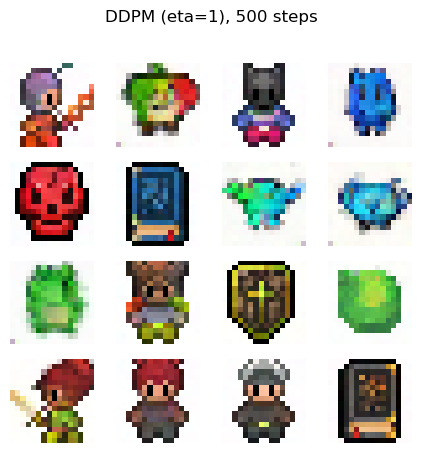

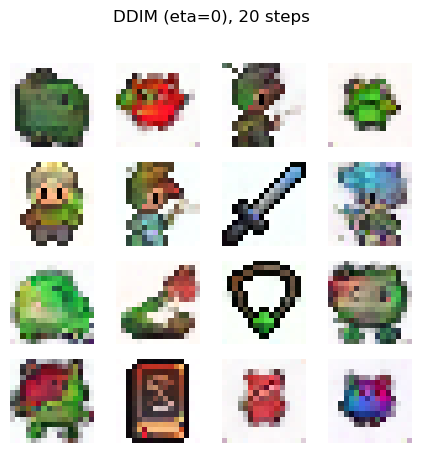

In [17]:
import time

def show_grid(samples, nrow=4, title=None):
    s = samples.detach().cpu()
    n = s.shape[0]; ncol = int(np.ceil(n / nrow))
    fig, axs = plt.subplots(nrow, ncol, figsize=(ncol * 1.1, nrow * 1.1))
    axs = np.array(axs).reshape(-1)
    for ax in axs:
        ax.axis('off')
    for k in range(n):
        img = (s[k].permute(1, 2, 0).clip(-1, 1).numpy() + 1) / 2
        axs[k].imshow(img)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout(); plt.show()

SEED = 0
# DDPM = eta=1 with all timesteps; DDIM = eta=0 with 20 steps. Same seed -> same x_T.
t0 = time.time(); ddpm_samples, _ = sample_ddim(16, n_steps=timesteps, eta=1.0, seed=SEED); t_ddpm = time.time() - t0
t0 = time.time(); ddim_samples, _ = sample_ddim(16, n_steps=20,        eta=0.0, seed=SEED); t_ddim = time.time() - t0
print(f"DDPM ({timesteps} steps): {t_ddpm:.1f}s     DDIM (20 steps): {t_ddim:.1f}s")
show_grid(ddpm_samples, title=f"DDPM (eta=1), {timesteps} steps")
show_grid(ddim_samples, title="DDIM (eta=0), 20 steps")


### Steps versus quality

Deterministic DDIM ($\eta=0$) from one fixed seed, at a few step budgets. Quality climbs quickly and then saturates: the gap between 20 and 50 steps is small, while 5 steps is visibly coarse.


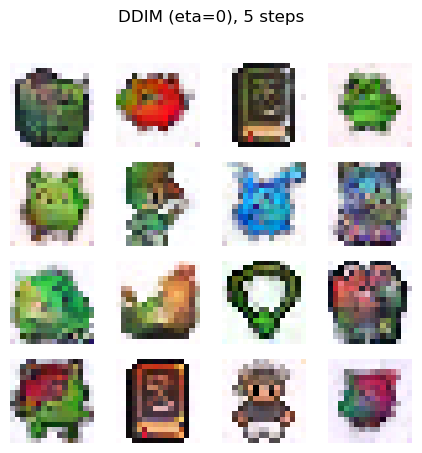

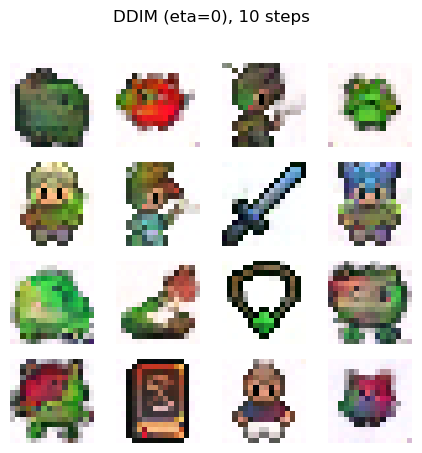

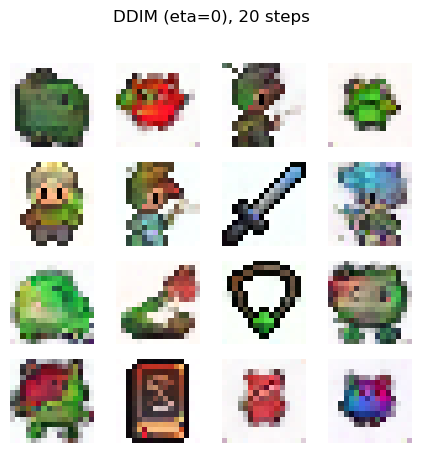

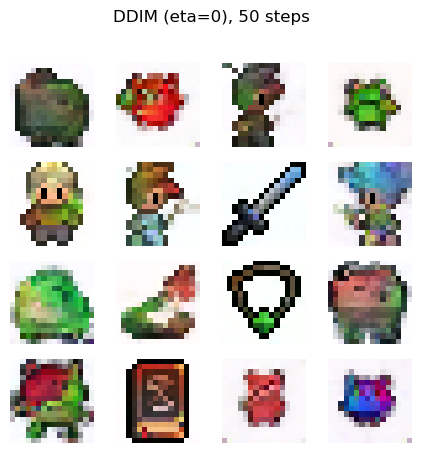

In [18]:
for n in [5, 10, 20, 50]:
    s, _ = sample_ddim(16, n_steps=n, eta=0.0, seed=SEED)
    show_grid(s, title=f"DDIM (eta=0), {n} steps")


### The $\eta$ knob

Fix the seed and the step count and sweep $\eta$ from 0 (deterministic) to 1 (fully stochastic). More $\eta$ means more fresh noise per step, so at a low step budget the higher-$\eta$ samples tend to look noisier; $\eta=0$ is the cleanest with few steps.


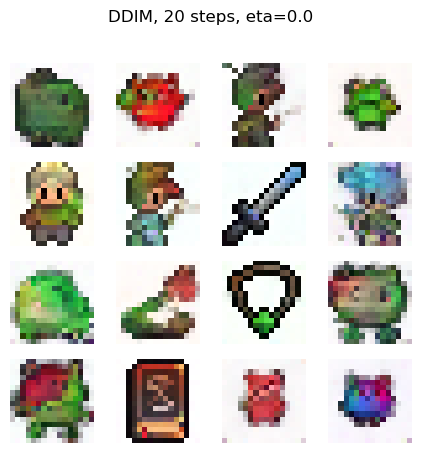

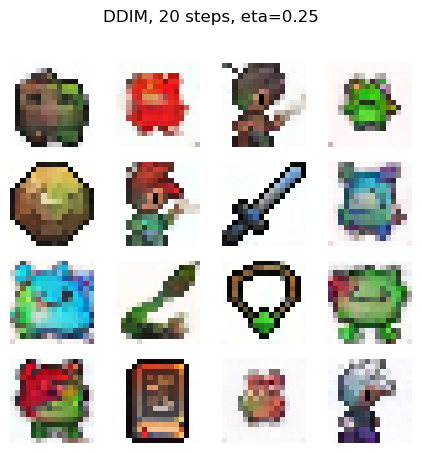

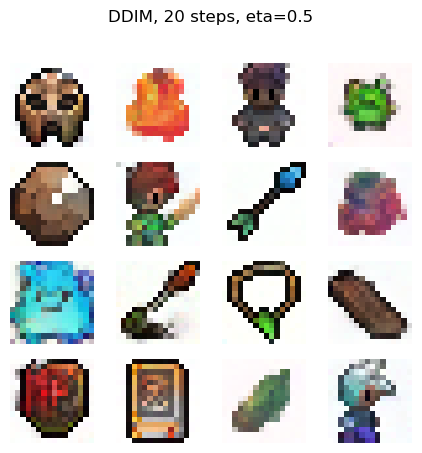

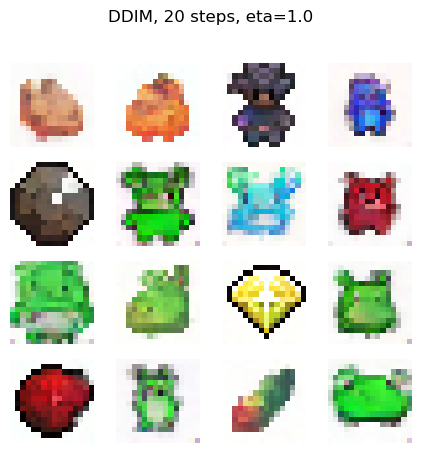

In [19]:
for eta in [0.0, 0.25, 0.5, 1.0]:
    s, _ = sample_ddim(16, n_steps=20, eta=eta, seed=SEED)
    show_grid(s, title=f"DDIM, 20 steps, eta={eta}")


### Latent interpolation (a DDIM bonus)

Because $\eta=0$ is a deterministic, invertible map from noise to image, interpolating between two starting noises and decoding each gives a smooth morph between sprites. We use spherical interpolation (slerp), which respects the Gaussian geometry of the latent space better than a straight line.


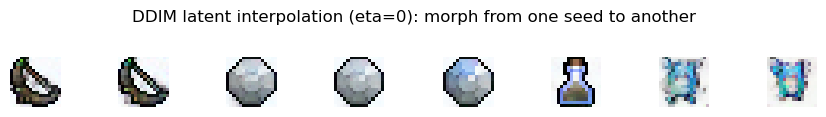

In [20]:
# spherical interpolation between two latents (respects the N(0,I) geometry)
def slerp(a, b, alpha):
    af, bf = a.flatten(), b.flatten()
    an, bn = af / af.norm(), bf / bf.norm()
    omega = torch.acos((an * bn).sum().clamp(-1, 1))
    so = torch.sin(omega)
    if so < 1e-6:
        out = (1 - alpha) * af + alpha * bf
    else:
        out = (torch.sin((1 - alpha) * omega) / so) * af + (torch.sin(alpha * omega) / so) * bf
    return out.view(3, height, height)

torch.manual_seed(1)
z_a = torch.randn(3, height, height, device=device)
z_b = torch.randn(3, height, height, device=device)
alphas = torch.linspace(0, 1, 8)
x_init = torch.stack([slerp(z_a, z_b, float(al)) for al in alphas]).to(device)

s, _ = sample_ddim(x_init.shape[0], n_steps=50, eta=0.0, x_init=x_init)
show_grid(s, nrow=1, title="DDIM latent interpolation (eta=0): morph from one seed to another")


## Discussion and takeaways <a id="discussion"></a>

- **One family.** DDPM is DDIM with $\eta=1$ and every step; deterministic DDIM is $\eta=0$. The reverse process was never unique, and training committed us only to the marginals, not to the Markov chain.
- **Why determinism still works.** With $\eta=0$ all randomness lives in the seed $x_T$. The trained denoiser keeps the marginals correct, so a fixed path still lands on the data.
- **Diversity.** DDPM can give different images from one seed (fresh noise each step). Deterministic DDIM gives one image per seed; vary the seed or raise $\eta$ for diversity.
- **Steps.** 20–50 steps are usually the sweet spot; around 10 is much faster but loses detail; one giant jump fails because the $t=T$ input is almost pure noise.
- **Bonus.** A deterministic, invertible map makes latent interpolation and editing possible, and in the continuous limit it is the probability-flow ODE.
- **Beyond.** The insight that the reverse process is not unique underlies modern few-step samplers such as consistency models and distillation.


## Acknowledgments
Sprites by ElvGames, [FrootsnVeggies](https://zrghr.itch.io/froots-and-veggies-culinary-pixels) and  [kyrise](https://kyrise.itch.io/)   
This code is modified from, https://github.com/cloneofsimo/minDiffusion   
Diffusion model is based on [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) and [Denoising Diffusion Implicit Models](https://arxiv.org/abs/2010.02502)
